5.0305 1.9224
[1.20475819e-12 1.32203442e-10]
[  5.03052628 289.84416052] [5.03052628 1.92235774]


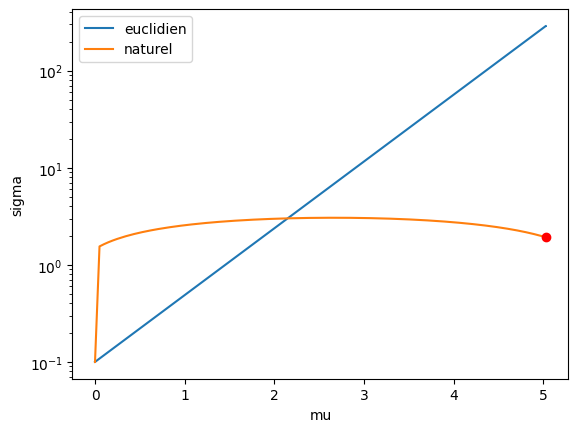

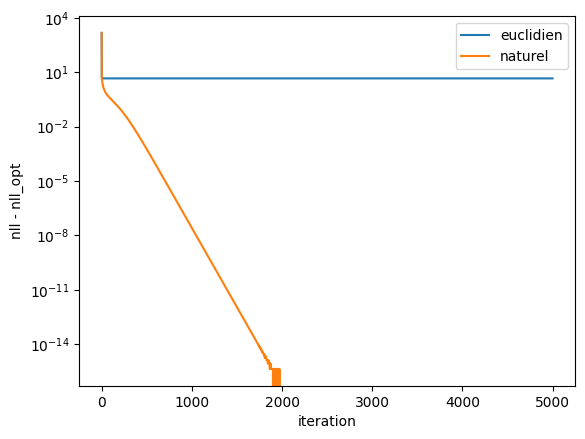

819
0
0.0 0.0


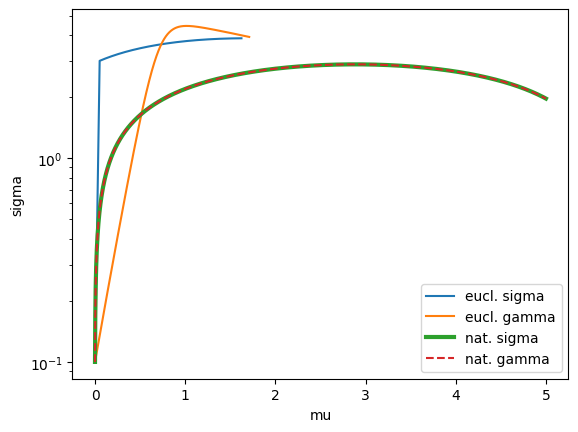

0.002875321493552019
eta=1e-03  n_iter=5000  ecart=1.812e-01
eta=5e-04  n_iter=10000  ecart=3.395e-02
eta=2e-04  n_iter=25000  ecart=6.447e-03
eta=1e-04  n_iter=50000  ecart=2.875e-03
eta=5e-05  n_iter=100000  ecart=1.378e-03
eta=2e-05  n_iter=249999  ecart=5.388e-04
eta=1e-05  n_iter=499999  ecart=2.675e-04


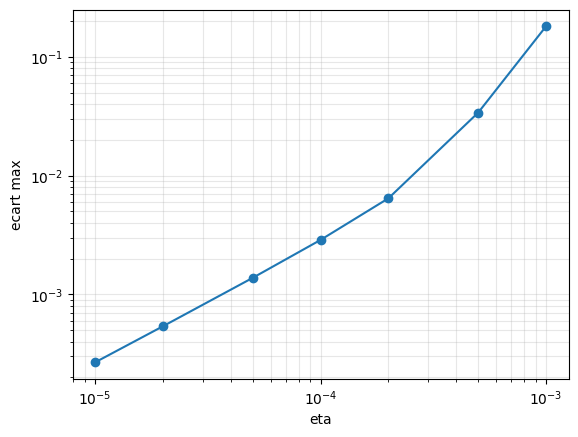

'the gap shrinks linearly with eta: both natural trajectories coincide\nin the continuous limit, what we see is only discretization error'

In [2]:
# 01_gaussian — natural gradient on a 1D Gaussian model
#Here: : Fisher matrix, natural vs euclidean descent, reparametrization invariance

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
x = rng.normal(5, 2, size=200)
print(f"{x.mean():.4f}", f"{x.std():.4f}")

mu = x.mean()
sigma = x.std()


def nll(x, mu, sigma):
    """Negative log-likelihood per data point of N(mu, sigma^2)."""
    return 0.5 * np.log(2 * np.pi * sigma**2) + ((x - mu)**2).mean() / (2 * sigma**2)


def grad_nll(x, mu, sigma):
    grad_mu = -(x - mu).mean() / sigma**2
    grad_sigma = 1/sigma - ((x - mu)**2).mean() / sigma**3
    return np.array([grad_mu, grad_sigma])


def grad_num(x, mu, sigma, eps=1e-5):
    """Numerical gradient (centered finite differences), to check grad_nll."""
    mu_num = (nll(x, mu + eps, sigma) - nll(x, mu - eps, sigma)) / (2 * eps)
    sigma_num = (nll(x, mu, sigma + eps) - nll(x, mu, sigma - eps)) / (2 * eps)
    return np.array([mu_num, sigma_num])


g_ana = grad_nll(x, 3.0, 1.5)
g_num = grad_num(x, 3.0, 1.5)
print(np.abs(g_ana - g_num) / np.abs(g_ana))


def fisher(sigma):  # simple case for Fisher
    return np.array([[1/sigma**2, 0], [0, 2/sigma**2]])  # V(s_mu) and V(s_sigma)


def descente(theta0, eta, n_iter, naturel=False):  # compact fonction
    theta = np.array(theta0, dtype=float)
    L = []
    for i in range(n_iter):
        L.append(theta.copy())
        grad = grad_nll(x, theta[0], theta[1])
        if naturel:
            grad = np.linalg.inv(fisher(theta[1])) @ grad  # sigma**3 => sigma
        theta = theta - eta * grad
    return np.array(L)


# 0.1 => grad_sigma much higher because of the 1/sigma**3
L_e = descente([0.0, 0.1], 0.01, 5000)
L_n = descente([0.0, 0.1], 0.01, 5000, naturel=True)
print(L_e[-1], L_n[-1])

""" there is a clear limit with the classic descent gradient,
moving from 0.1 to 0.2 is way different than moving from 100 to 100.1 """

plt.plot(L_e[:, 0], L_e[:, 1], label="euclidien")
plt.plot(L_n[:, 0], L_n[:, 1], label="naturel")
plt.scatter(5.0305, 1.9224, color="red", zorder=5)
plt.yscale("log")
plt.xlabel("mu"); plt.ylabel("sigma"); plt.legend()
plt.show()

nll_opt = nll(x, x.mean(), x.std())
e_e = np.array([nll(x, t[0], t[1]) for t in L_e]) - nll_opt
e_n = np.array([nll(x, t[0], t[1]) for t in L_n]) - nll_opt

plt.plot(e_e, label="euclidien")
plt.plot(e_n, label="naturel")
plt.yscale("log")
plt.xlabel("iteration"); plt.ylabel("nll - nll_opt"); plt.legend()
plt.show()

print(np.argmax(e_n < 1e-6))
print(np.argmax(e_e < 1e-6))  # never !!!


def nll_ln(x, mu, gamma):
    sigma = np.exp(gamma)
    return nll(x, mu, sigma)  # gamma = log(sigma) or sigma = exp(gamma)


def grad_nll_ln(x, mu, gamma):
    sigma = np.exp(gamma)
    grad_nll_cl = grad_nll(x, mu, sigma)
    return np.array([grad_nll_cl[0], grad_nll_cl[1] * sigma])


def fisher_ln(gamma):
    sigma = np.exp(gamma)
    return np.array([[1/sigma**2, 0], [0, 2]])  # V(s_mu) and V(s_gamma)


# sigma=1.5, grad_nll[1]*1.5 == grad_nll_ln[1], ok with chain rule
g_s = grad_nll(x, 3.0, 1.5)
g_g = grad_nll_ln(x, 3.0, np.log(1.5))
print(g_s[0] - g_g[0], g_s[1] * 1.5 - g_g[1])


def descente_ln(theta0, eta, n_iter, naturel=False):
    theta = np.array(theta0, dtype=float)
    L = []
    for i in range(n_iter):
        L.append(theta.copy())
        grad = grad_nll_ln(x, theta[0], theta[1])
        if naturel:
            grad = np.linalg.inv(fisher_ln(theta[1])) @ grad
        theta = theta - eta * grad
    return np.array(L)


L_e_s = descente([0.0, 0.1], 0.0001, 50000)
L_n_s = descente([0.0, 0.1], 0.0001, 50000, naturel=True)
L_e_g = descente_ln([0.0, np.log(0.1)], 0.0001, 50000)
L_n_g = descente_ln([0.0, np.log(0.1)], 0.0001, 50000, naturel=True)

L_e_g_c = L_e_g.copy(); L_e_g_c[:, 1] = np.exp(L_e_g[:, 1])
L_n_g_c = L_n_g.copy(); L_n_g_c[:, 1] = np.exp(L_n_g[:, 1])

plt.plot(L_e_s[:, 0], L_e_s[:, 1], label="eucl. sigma")
plt.plot(L_e_g_c[:, 0], L_e_g_c[:, 1], label="eucl. gamma")
plt.plot(L_n_s[:, 0], L_n_s[:, 1], '-', label="nat. sigma", lw=3)
plt.plot(L_n_g_c[:, 0], L_n_g_c[:, 1], '--', label="nat. gamma")
plt.yscale("log")
plt.xlabel("mu"); plt.ylabel("sigma"); plt.legend()
plt.show()

# same ! same distribution, space of distributions not parameters
print(np.linalg.norm(L_n_g_c - L_n_s, axis=1).max())

"""error depending on the value of eta"""

etas = [1e-3, 5e-4, 2e-4, 1e-4, 5e-5, 2e-5, 1e-5]
ecarts = []

for eta in etas:
    n_iter = int(5 / eta)  # keep eta * n_iter constant
    Ln_s = descente([0.0, 0.1], eta, n_iter, naturel=True)
    Ln_g = descente_ln([0.0, np.log(0.1)], eta, n_iter, naturel=True)
    Ln_g_c = Ln_g.copy(); Ln_g_c[:, 1] = np.exp(Ln_g[:, 1])
    ecart = np.linalg.norm(Ln_g_c - Ln_s, axis=1).max()
    ecarts.append(ecart)
    print(f"eta={eta:.0e}  n_iter={n_iter}  ecart={ecart:.3e}")

plt.loglog(etas, ecarts, 'o-')
plt.grid(True, which="both", alpha=0.3)
plt.xlabel("eta"); plt.ylabel("ecart max")
plt.show()

"""the gap shrinks linearly with eta: both natural trajectories coincide
in the continuous limit, what we see is only discretization error"""